In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pymplot as plt
import plotly.express as px

In [59]:
from pathlib import Path
data_folder = Path("../data/raw/CICIDS2017")
csv_files = list(data_folder.glob("*.csv"))

for i, file in enumerate(csv_files, start = 1):
  data = pd.read_csv(file)
  rows, cols = data.shape
  print(f'Data{i} -> {rows} rows, {cols} columns')

df = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True) #huge dataframe with all the rows from all 8 csv files combined
df.columns = df.columns.str.strip()

# for file in csv_files:
#     print(file.name)
    
df.head() #first 5 rows
row, col = df.shape
print(f"row: {row}")
print(f"col: {col}")

Data1 -> 288602 rows, 79 columns
Data2 -> 529918 rows, 79 columns
Data3 -> 191033 rows, 79 columns
Data4 -> 286467 rows, 79 columns
Data5 -> 225745 rows, 79 columns
Data6 -> 445909 rows, 79 columns
Data7 -> 692703 rows, 79 columns
Data8 -> 170366 rows, 79 columns
row: 2830743
col: 79


### Missing Values (NaNs)

Flow Bytes/s contains 1,358 missing values due to undefined calculations from zero-duration flows.
Flow Bytes/s = Total Bytes / Flow Duration

These missing values will be handled during preprocessing by replacing them with the median value of the feature.

ex:
df["Flow Bytes/s"] = df["Flow Bytes/s"].fillna(
    df["Flow Bytes/s"].median()
)

In [ ]:
import numpy as np

df.isnull().sum().sort_values(ascending=False).head(10)

Flow Bytes/s            1358
Destination Port           0
Bwd Avg Bytes/Bulk         0
Fwd Avg Packets/Bulk       0
Fwd Avg Bytes/Bulk         0
Fwd Header Length.1        0
Avg Bwd Segment Size       0
Avg Fwd Segment Size       0
Average Packet Size        0
Down/Up Ratio              0
dtype: int64

### Dataframe Info
2,830,743 rows after combining 8 csv files

79 cols, 78 features, 1 label

In [15]:
print("shape:", df.shape) #(rows, cols)

# print("info")
df.info()
df.count
# print("describe")
df.describe()


shape: (2830743, 79)
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int

/Users/snehathomas/IDS/Network_IDS/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/snehathomas/IDS/Network_IDS/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


### Class distribution

In [ ]:
#class distribution
df["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [24]:
# class imbalance
df["Label"].value_counts(normalize=True) * 100


Label
BENIGN                        80.300366
DoS Hulk                       8.162981
PortScan                       5.614427
DDoS                           4.522735
DoS GoldenEye                  0.363615
FTP-Patator                    0.280421
SSH-Patator                    0.208320
DoS slowloris                  0.204752
DoS Slowhttptest               0.194260
Bot                            0.069452
Web Attack � Brute Force       0.053237
Web Attack � XSS               0.023033
Infiltration                   0.001272
Web Attack � Sql Injection     0.000742
Heartbleed                     0.000389
Name: proportion, dtype: float64

### Imbalance Graph
HIGH imbalance; BENIGN is the dominant class.

Heartbleed has the smallest appearance.


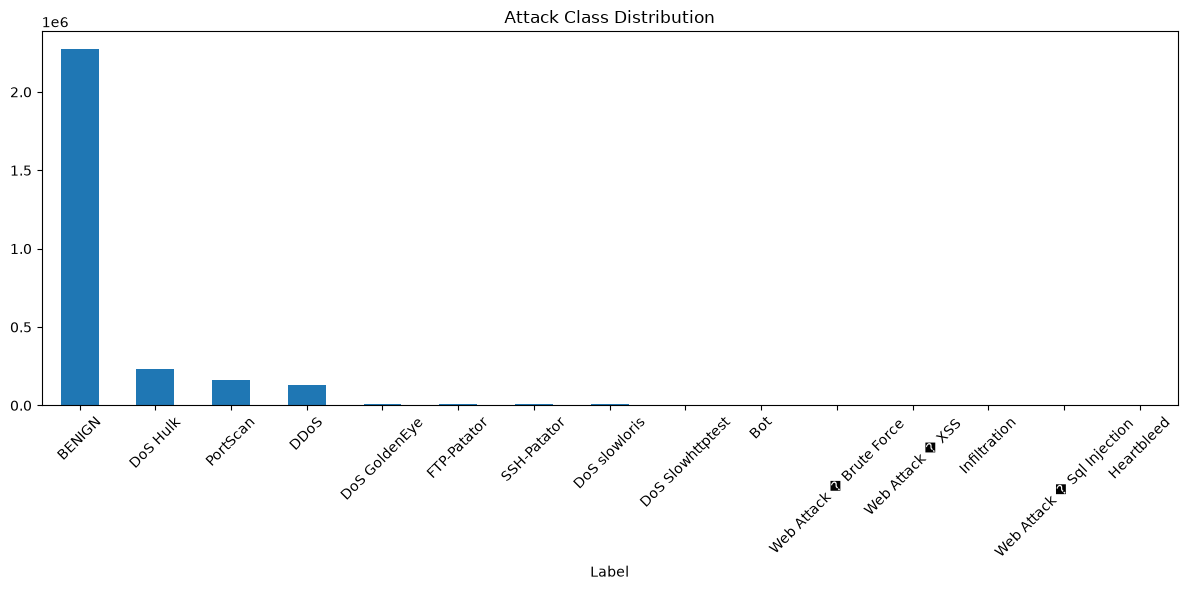

In [26]:
label_counts = df["Label"].value_counts()

plt.figure(figsize=(12,6))
label_counts.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Attack Class Distribution")
plt.tight_layout()
plt.show()

### Duplicates
The dataset contains 308,381 duplicate rows (~10.9% of the dataset). These duplicates will be removed during preprocessing to prevent the model from seeing repeated examples and artificially inflated evaluation performance.

In [ ]:
df.duplicated().sum()

np.int64(308381)

Only Flow Bytes/s has missing values: 1,358 missing values

In [31]:
df.isnull().sum().sort_values(ascending=False)

Flow Bytes/s            1358
Destination Port           0
Bwd Avg Bytes/Bulk         0
Fwd Avg Packets/Bulk       0
Fwd Avg Bytes/Bulk         0
                        ... 
Bwd IAT Mean               0
Bwd IAT Total              0
Fwd IAT Min                0
Fwd IAT Max                0
Label                      0
Length: 79, dtype: int64

Flow packets/s and Flow Bytes/s both have infinite values:

Flow Packets/s:          2867

Flow Bytes/s:            1509

These probably occur because rate-based features divide by flow duration, and flows with zero duration result in undefined values.

In [33]:
np.isinf(df.select_dtypes(include=np.number)).sum().sort_values(ascending=False)

Flow Packets/s          2867
Flow Bytes/s            1509
Destination Port           0
Down/Up Ratio              0
Fwd Avg Packets/Bulk       0
                        ... 
Bwd IAT Mean               0
Bwd IAT Total              0
Fwd IAT Min                0
Fwd IAT Max                0
Idle Min                   0
Length: 78, dtype: int64

### Feature Distributions

Made copy so that inf values for flow bytes and flow packets can be ignored JUST for eda. Will be fixed in preprocessing.

Update: Flow Bytes/s and Flow Packets/s contained invalid values (infinite and negative values), probably caused by rate calculations w zero-duration flows. Invalid values were filtered for visualization and will be fixed during preprocessing.

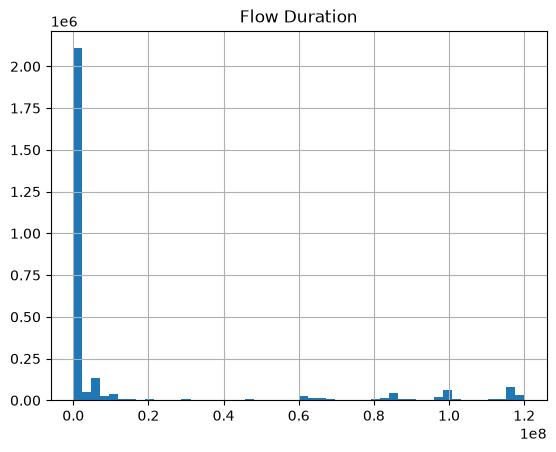

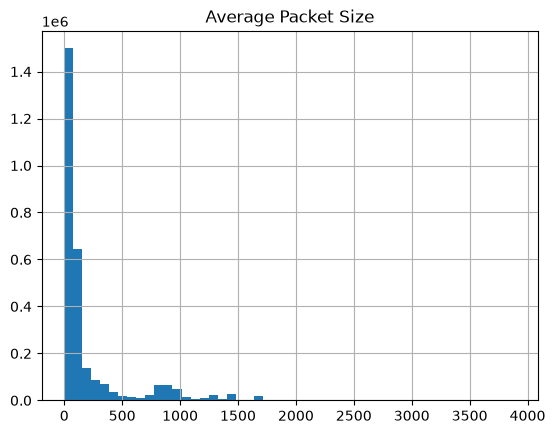

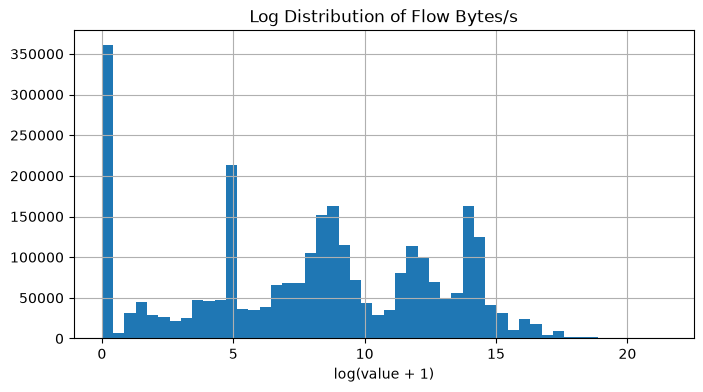

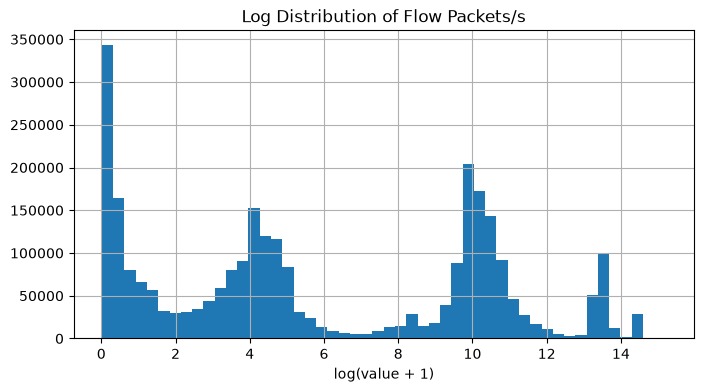

In [41]:
eda_df = df.copy()
eda_df.replace([np.inf, -np.inf], np.nan, inplace=True) #made copy so that inf values for flow bytes and flow packets can be ignored JUST for eda. 

features = [
    "Flow Duration",
    "Average Packet Size",
    ]

for i in features:
    df[i].hist(bins=50)
    plt.title(i)
    plt.show()
    
#instead of using eda_df for flow bytes and packets, did log graph for them instead
for feature in ["Flow Bytes/s", "Flow Packets/s"]:
    plt.figure(figsize=(8,4))

    temp = eda_df[feature].dropna()
    temp = temp[temp >= 0]

    np.log1p(temp).hist(bins=50)

    plt.title(f"Log Distribution of {feature}")
    plt.xlabel("log(value + 1)")
    plt.show()

### Correlation

Correlation matrix heatmap.

Both x and y axes are the same list of numeric features, just indexed by position (0 through ~77).

Watch out for **multicollinearity**: when two or more features contain almost the same information. (dark red boxes)

Log. Reg. model predicition score = (feature1​×coefficient1​)+(feature2​×coefficient2​)+...+bias


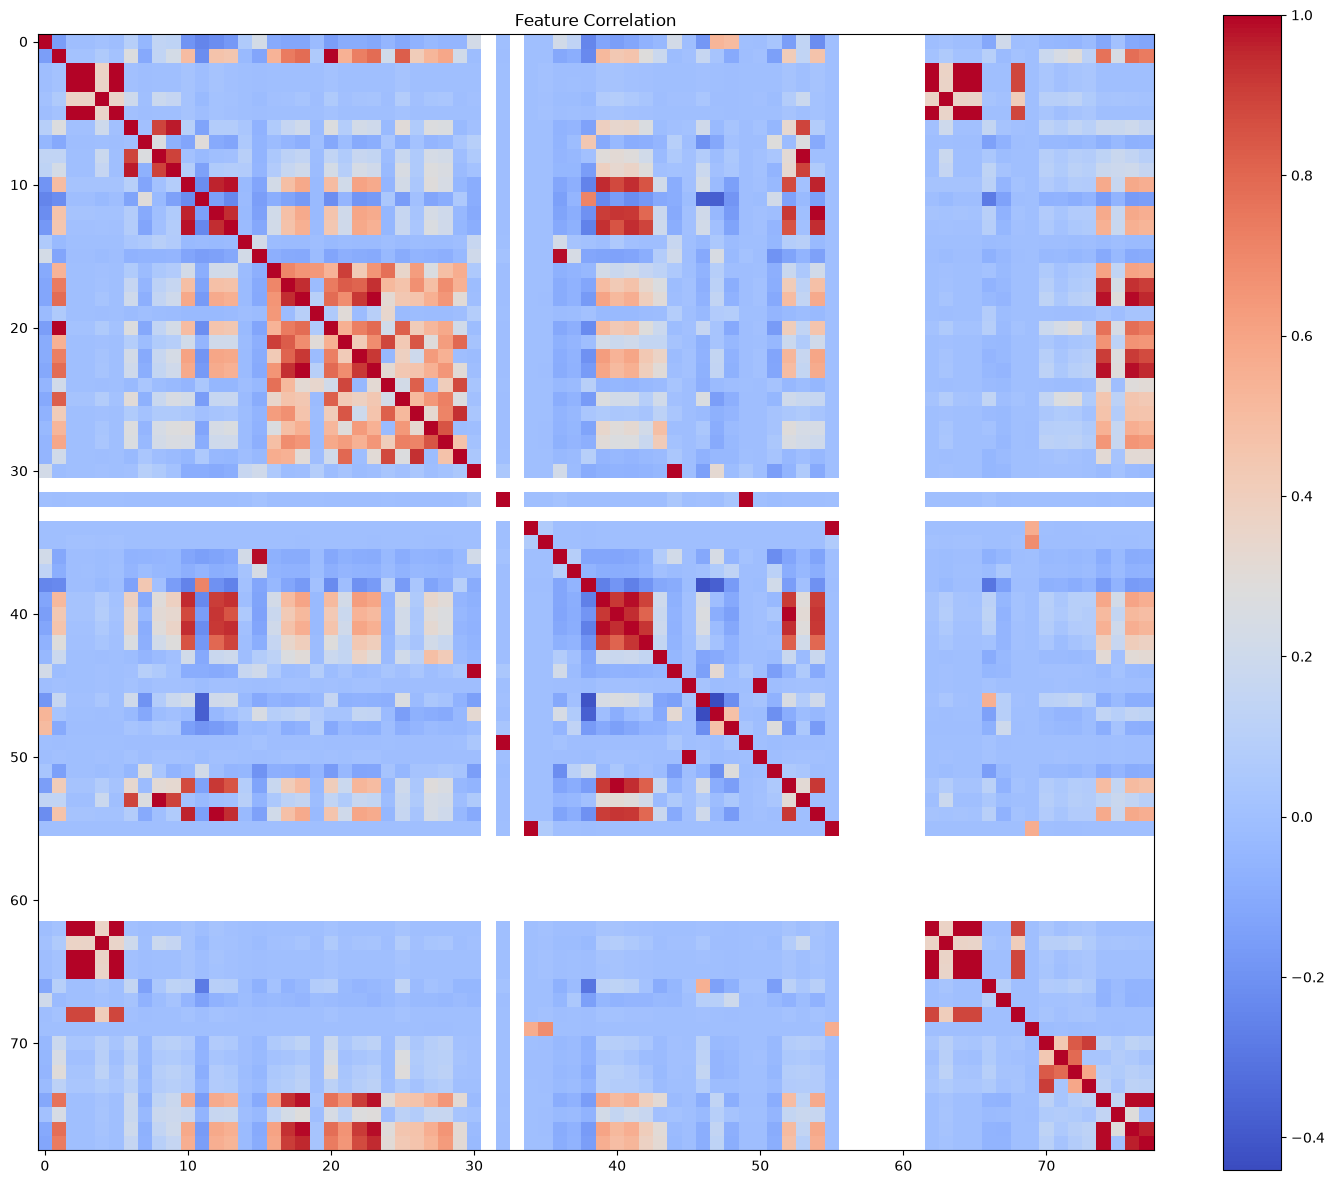

In [42]:
numeric_df = df.select_dtypes(include=np.number) #remove label temporarily
corr = numeric_df.corr()

plt.figure(figsize=(18,15))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Feature Correlation")
plt.show()

In [43]:
# find correlation pairs

corr_matrix = df.select_dtypes(include=np.number).corr()

high_corr = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr[high_corr > 0.85]

Total Fwd Packets       Subflow Fwd Packets       1.000000
Fwd Header Length       Fwd Header Length.1       1.000000
Fwd URG Flags           CWE Flag Count            1.000000
Fwd PSH Flags           SYN Flag Count            1.000000
Total Backward Packets  Subflow Bwd Packets       1.000000
                                                    ...   
Bwd Packet Length Max   Average Packet Size       0.875633
Fwd IAT Std             Idle Min                  0.875566
Bwd Packet Length Max   Packet Length Variance    0.853215
Bwd Packet Length Std   Packet Length Mean        0.851543
                        Average Packet Size       0.850800
Length: 91, dtype: float64

In [ ]:
df[["Fwd URG Flags", "CWE Flag Count"]].describe()

np.True_

### VIF - Variance Inflation Factor
Correlation only compares two features at a time.
VIF measures whether one feature can be explained by all the other features together, meaning that it checks for multicollinearity between features.

VIF meanings:
 
VIF = 1 → Independent of the others.<br>
VIF = 5–10 → Moderate multicollinearity.<br>
VIF > 10 → High multicollinearity.<br>
VIF = ∞ → Perfectly predictable from the other features.<br>

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Clean numeric data
vif_df = df.select_dtypes(include=np.number).copy()

vif_df.replace([np.inf, -np.inf], np.nan, inplace=True)
vif_df = vif_df.fillna(vif_df.median())

# Remove exact duplicate features found during EDA
vif_df = vif_df.drop(columns=[
    "Subflow Fwd Packets",
    "Subflow Bwd Packets",
    "Fwd Header Length.1",
    "CWE Flag Count",
    "SYN Flag Count"
])

# Sample 50,000 rows (much faster)
sample = vif_df.sample(n=50000, random_state=42)

# Calculate VIF
vif = pd.DataFrame({
    "Feature": sample.columns,
    "VIF": [
        variance_inflation_factor(sample.values, i)
        for i in range(sample.shape[1])
    ]
})

vif = vif.sort_values("VIF", ascending=False)

vif.head(20)
# vif.tail(20)

/Users/snehathomas/IDS/Network_IDS/.venv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/Users/snehathomas/IDS/Network_IDS/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
4,Total Length of Fwd Packets,inf
8,Fwd Packet Length Mean,inf
59,Subflow Fwd Bytes,inf
52,Avg Bwd Segment Size,inf
51,Avg Fwd Segment Size,inf
12,Bwd Packet Length Mean,inf
48,ECE Flag Count,inf
44,RST Flag Count,inf
5,Total Length of Bwd Packets,1.176216e+08
60,Subflow Bwd Bytes,1.176131e+08


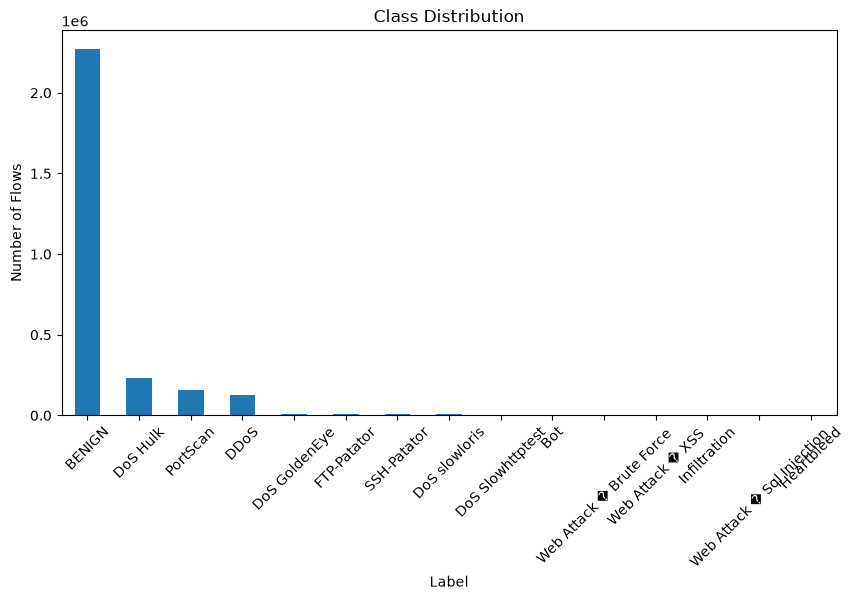

In [56]:
label_counts = df["Label"].value_counts()

plt.figure(figsize=(10,5))
label_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Number of Flows")
plt.xticks(rotation=45)
plt.show()